# Import modules

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import anndata
import os
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
# enables correct plotting of text
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42 

sc.settings.verbosity = 1  # verbosity: errors (0), warnings (1), info (2), hints (3)

In [2]:
import importlib.util
import sys
spec = importlib.util.spec_from_file_location("module.name", "/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py")
utils = importlib.util.module_from_spec(spec)
sys.modules["module.name"] = utils
spec.loader.exec_module(utils)

/rfs/project/rfs-iCNyzSAaucw/kk837/function/python/utils.py:356: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if sc.__version__.startswith("1.4"):


In [3]:
figdir = '/rfs/project/rfs-iCNyzSAaucw/kk837/notebooks/Foetal/Revision_Oct2025/fetal_ms_figures'
os.makedirs(figdir,exist_ok=True)
# table_dir = '/nfs/team205/heart/fetal_ms_figures/tables/Aug2024'

In [4]:
sc.settings.set_figure_params(dpi=120)

# Variables

In [6]:
data_object_dir = '/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025'
path_adata_tacco = f'{data_object_dir}/TACCO/tacco-splitted_ref-HD-SCN_filtered_rm-unclassified_raw.h5ad'
path_adata_original = f'{data_object_dir}/all_b2c_cells_filtered_celltype-sel_rm-unclassified_raw.h5ad'

# Read in post-TACCO VisiumHD adata

In [7]:
# read in tacco-treated adata
adata_tacco = sc.read_h5ad(path_adata_tacco)
adata_tacco

AnnData object with n_obs × n_vars = 189948 × 18077
    obs: 'object_id', 'bin_count', 'array_row', 'array_col', 'labels_joint_source', 'in_tissue_manual', 'library', 'donor_section_ID', 'per-frame_donorIDs', 'donor', 'CS', 'est_CS', 'GA', 'PCW', 'section_ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'library_donor', 'n_genes', 'coarse_grain_pre', 'coarse_grain_pre_2', 'coarse_grain_tacco_ref-hd-scn', 'original_cellid_celltype', 'tacco_max_compscore', 'fine_grain_2Feb2026'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'PCW_colors', 'coarse_grain_pre_2_colors', 'coarse_grain_tacco_ref-hd-scn_colors', 'donor_colors', 'library_col

In [8]:
set(adata_tacco.obs['fine_grain_2Feb2026'])

{'ArterialEndothelialCells',
 'AtrialCardiomyocytesLeft',
 'AtrialCardiomyocytesNeurotropic',
 'AtrialCardiomyocytesRight',
 'AtrialCardiomyocytesTransitional',
 'AtrioventricularNodePacemakerCells',
 'CoronaryCapillaryEndothelialCells',
 'CoronaryMuralCells',
 'DuctusArteriosusSmoothMuscleCells',
 'EndocardialCells',
 'EpicardiumDerivedCells',
 'Fibroblasts',
 'FibroblastsCOL2A1pos',
 'FibroblastsPITX2pos',
 'GreatVesselSmoothMuscleCells',
 'InnateLymphoidCells',
 'LymphaticEndothelialCells',
 'MacrophagesCX3CR1pos',
 'MacrophagesLYVE1pos',
 'MesothelialEpicardialCells',
 'Monocytes',
 'NaturalKillerCells',
 'ParasympatheticNeurons',
 'SchwannCells',
 'SinoatrialNodePacemakerCellsHead',
 'SinoatrialNodePacemakerCellsTail',
 'SinusHornPacemakerCells',
 'SympatheticNeurons',
 'ValveEndothelialCells',
 'ValveInterstitialCells',
 'VenousEndothelialCells',
 'VentricularCardiomyocytesCompact',
 'VentricularCardiomyocytesTrabeculated',
 'VentricularConductionSystemDistal',
 'VentricularCondu

# Create mid-grained cell type labels

In [9]:
!ls /rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/RNA

Feb28ObjectRaw_finegrain_updated_celltype-labels.csv
Feb28ObjectRaw_finegrain_updated_CMs_multiomeRNA_subsampled-per-finegrained-n1000.h5ad
Feb28ObjectRaw_finegrain_updated.h5ad
Feb28ObjectRaw_finegrain_updated_SANPC.h5ad
Feb28ObjectRaw_finegrain_updated_SANPC_with-adult.h5ad
Feb28ObjectRaw_finegrain_updated_SANPC_with-adult_pseudobulk-donor_lognorm.h5ad
Feb28ObjectRaw_finegrain_updated_workingCM_with-adult.h5ad
Feb28ObjectRaw_finegrain_updated_workingCM_with-adult_pseudobulk-donor_lognorm.h5ad
Feb28ObjectRaw_genomic-features.csv


In [10]:
# mig-grained labels from scnRNAseq
ad = sc.read_h5ad('/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/RNA/Feb28ObjectRaw_finegrain_updated.h5ad',
                 backed='r')
set(ad.obs['mid_grain'])

{'AtrialCardiomyocytes',
 'BloodVesselEndothelialCells',
 'CardiacConductionSystem',
 'EndocardialCells',
 'EpicardialCells',
 'Fibroblasts',
 'Glia',
 'LymphaticEndothelialCells',
 'LymphoidCells',
 'MuralCells',
 'MyeloidCells',
 'Neurons',
 'PericardialCells',
 'VentricularCardiomyocytes'}

In [11]:
fine2mid_mapping = {
    'AtrialCardiomyocytesLeft':'AtrialCardiomyocytes',
     'AtrialCardiomyocytesNeurotropic':'AtrialCardiomyocytes',
     'AtrialCardiomyocytesRight':'AtrialCardiomyocytes',
     'AtrialCardiomyocytesTransitional':'AtrialCardiomyocytes',
    
    'VentricularCardiomyocytesCompact':'VentricularCardiomyocytes',
     'VentricularCardiomyocytesTrabeculated':'VentricularCardiomyocytes',
     'VentricularConductionSystemDistal':'VentricularCardiomyocytes',
     'VentricularConductionSystemProximal':'VentricularCardiomyocytes',
    
    'SinoatrialNodePacemakerCellsHead':'CardiacConductionSystem',
     'SinoatrialNodePacemakerCellsTail':'CardiacConductionSystem',
     'SinusHornPacemakerCells':'CardiacConductionSystem',
    'AtrioventricularNodePacemakerCells':'CardiacConductionSystem',
    
    'ArterialEndothelialCells':'BloodVesselEndothelialCells',
    'CoronaryCapillaryEndothelialCells':'BloodVesselEndothelialCells',
    'VenousEndothelialCells':'BloodVesselEndothelialCells',
    
    'EndocardialCells':'EndocardialCells',
    'ValveEndothelialCells':'EndocardialCells',
    
    'LymphaticEndothelialCells':'LymphaticEndothelialCells',
    
    'EpicardiumDerivedCells':'EpicardialCells',
    'MesothelialEpicardialCells':'EpicardialCells',
     
    'Fibroblasts':'Fibroblasts',
     'FibroblastsCOL2A1pos':'Fibroblasts',
     'FibroblastsPITX2pos':'Fibroblasts',
    'ValveInterstitialCells':'Fibroblasts',
     
     'CoronaryMuralCells':'MuralCells',
     'DuctusArteriosusSmoothMuscleCells':'MuralCells',
    'GreatVesselSmoothMuscleCells':'MuralCells',
    
    'ParasympatheticNeurons':'Neurons',
    'SympatheticNeurons':'Neurons',
    
    'SchwannCells':'Glia',
    
    'MacrophagesCX3CR1pos':'MyeloidCells',
     'MacrophagesLYVE1pos':'MyeloidCells',
     'Monocytes':'MyeloidCells',
    
     'NaturalKillerCells':'LymphoidCells',
    'InnateLymphoidCells':'LymphoidCells',
}

In [12]:
adata_tacco.obs['mid_grain_2Feb2026'] = adata_tacco.obs['fine_grain_2Feb2026'].astype('str').copy()
adata_tacco.obs.replace({'mid_grain_2Feb2026':fine2mid_mapping},inplace=True)
pd.crosstab(adata_tacco.obs['fine_grain_2Feb2026'],adata_tacco.obs['mid_grain_2Feb2026'])

mid_grain_2Feb2026,AtrialCardiomyocytes,BloodVesselEndothelialCells,CardiacConductionSystem,EndocardialCells,EpicardialCells,Fibroblasts,Glia,LymphaticEndothelialCells,LymphoidCells,MuralCells,MyeloidCells,Neurons,VentricularCardiomyocytes
fine_grain_2Feb2026,,,,,,,,,,,,,
ArterialEndothelialCells,0,724,0,0,0,0,0,0,0,0,0,0,0
AtrialCardiomyocytesLeft,8366,0,0,0,0,0,0,0,0,0,0,0,0
AtrialCardiomyocytesNeurotropic,123,0,0,0,0,0,0,0,0,0,0,0,0
AtrialCardiomyocytesRight,9684,0,0,0,0,0,0,0,0,0,0,0,0
AtrialCardiomyocytesTransitional,1604,0,0,0,0,0,0,0,0,0,0,0,0
AtrioventricularNodePacemakerCells,0,0,5661,0,0,0,0,0,0,0,0,0,0
CoronaryCapillaryEndothelialCells,0,340,0,0,0,0,0,0,0,0,0,0,0
CoronaryMuralCells,0,0,0,0,0,0,0,0,0,1056,0,0,0
DuctusArteriosusSmoothMuscleCells,0,0,0,0,0,0,0,0,0,2461,0,0,0


In [13]:
set(adata_tacco.obs['mid_grain_2Feb2026'])

{'AtrialCardiomyocytes',
 'BloodVesselEndothelialCells',
 'CardiacConductionSystem',
 'EndocardialCells',
 'EpicardialCells',
 'Fibroblasts',
 'Glia',
 'LymphaticEndothelialCells',
 'LymphoidCells',
 'MuralCells',
 'MyeloidCells',
 'Neurons',
 'VentricularCardiomyocytes'}

In [14]:
adata_tacco.obs['mid_grain_2Feb2026'] = pd.Categorical(
    adata_tacco.obs['mid_grain_2Feb2026'],
    categories=[
        'AtrialCardiomyocytes',
        'VentricularCardiomyocytes',
        'CardiacConductionSystem',
        'Fibroblasts',
        'MuralCells',
        'BloodVesselEndothelialCells',
        'EndocardialCells',
        'LymphaticEndothelialCells',
        'EpicardialCells',
        'Neurons',
        'Glia',
        'MyeloidCells',
        'LymphoidCells',
    ],
    ordered=True
)

# Plot

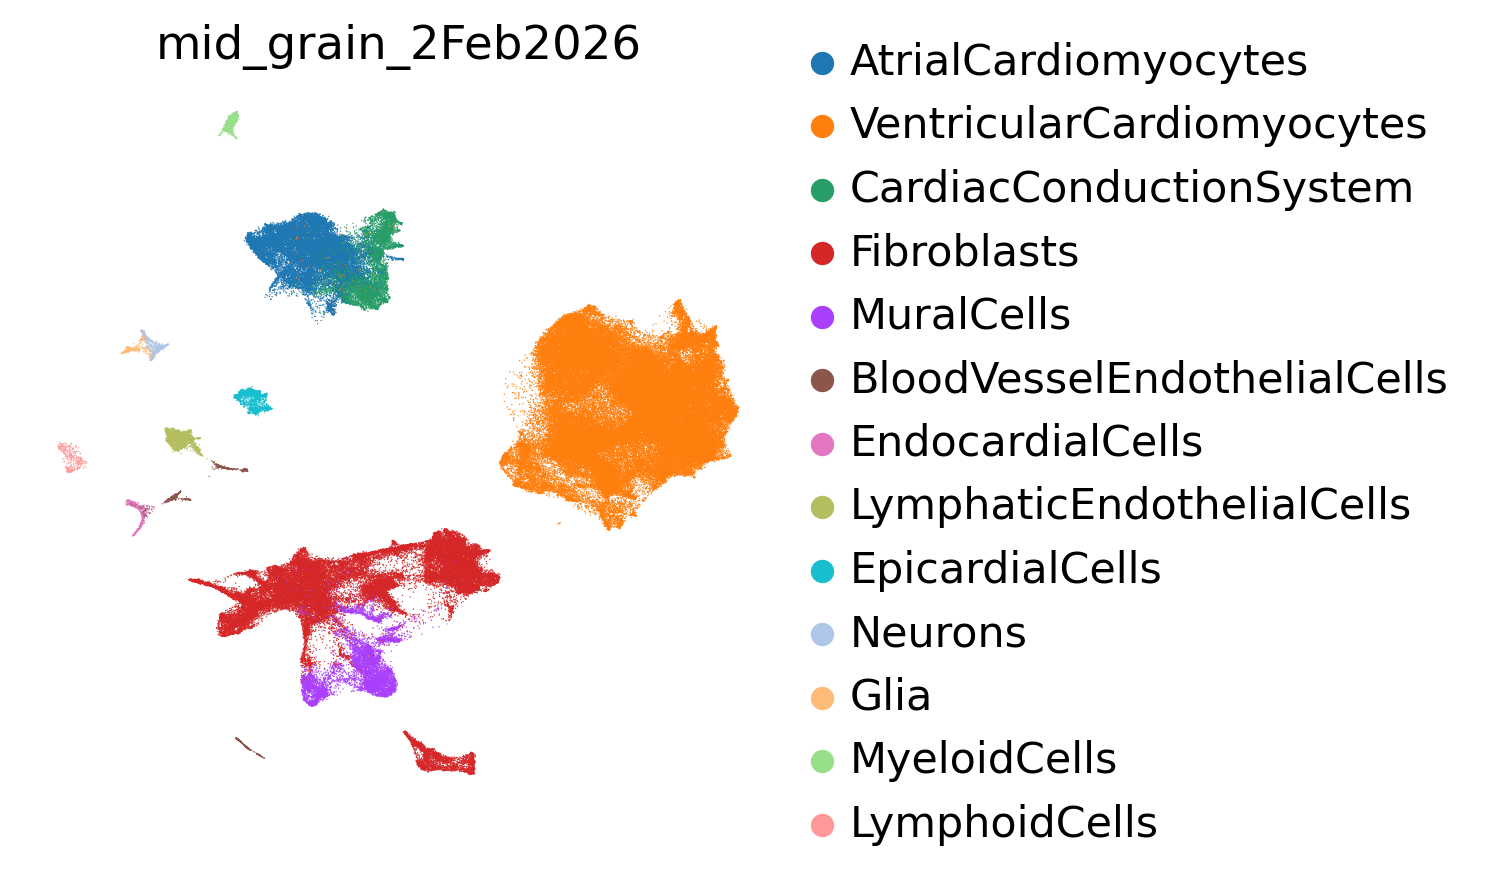

In [15]:
sc.pl.embedding(adata_tacco, basis='X_umap_scVI_n-layers-3',
               color='mid_grain_2Feb2026',
                frameon=False,
               show=False)
plt.savefig(f'{figdir}/VisiumHD_UMAP_midgrain.pdf', bbox_inches="tight",dpi=300)

# Save

In [16]:
adata_tacco.write(path_adata_tacco)
print(path_adata_tacco)

/rfs/project/rfs-iCNyzSAaucw/kk837/data_objects/Foetal/VisiumHD/Revision_Oct2025/TACCO/tacco-splitted_ref-HD-SCN_filtered_rm-unclassified_raw.h5ad
